# Proyecto Ciencia de Datos
Limpieza y Transformación de Datos

In [46]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv('/content/hourlySteps_merged.csv')
df.head()

,Id,ActivityHour,StepTotal
0,1503960366,3/12/2016 12:00:00 AM,0
1,1503960366,3/12/2016 1:00:00 AM,0
2,1503960366,3/12/2016 2:00:00 AM,0
3,1503960366,3/12/2016 3:00:00 AM,0
4,1503960366,3/12/2016 4:00:00 AM,0


# Exploración Inicial

In [48]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24084 entries, 0 to 24083
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            24084 non-null  int64 
 1   ActivityHour  24084 non-null  object
 2   StepTotal     24084 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 564.6+ KB


,0
Id,0
ActivityHour,0
StepTotal,0


# Verificar carga de datos

In [49]:
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (24084, 3)


,Id,ActivityHour,StepTotal
0,1503960366,3/12/2016 12:00:00 AM,0
1,1503960366,3/12/2016 1:00:00 AM,0
2,1503960366,3/12/2016 2:00:00 AM,0
3,1503960366,3/12/2016 3:00:00 AM,0
4,1503960366,3/12/2016 4:00:00 AM,0


In [50]:
import pandas as pd
import numpy as np

# Cargar dataset original
df = pd.read_csv('/content/hourlySteps_merged.csv')

# -----------------------------
# 1. DUPLICAR FILAS
# -----------------------------
df_duplicado = df.sample(frac=0.2, random_state=42)  # duplica 20%
df_sucio = pd.concat([df, df_duplicado], ignore_index=True)

print("Filas originales:", df.shape[0])
print("Filas después de duplicar:", df_sucio.shape[0])

# -----------------------------
# 2. AGREGAR NULOS
# -----------------------------
# porcentaje de nulos
porcentaje_nulos = 0.05  # 5%

for col in df_sucio.columns:
    df_sucio.loc[
        df_sucio.sample(frac=porcentaje_nulos).index, col
    ] = np.nan

# -----------------------------
# 3. GUARDAR DATASET SUCIO
# -----------------------------
df_sucio.to_csv('/content/hourlySteps_sucio.csv', index=False)

print("Dataset sucio creado ✅")

Filas originales: 24084
Filas después de duplicar: 28901
Dataset sucio creado ✅


In [51]:
print("Nulos por columna:")
print(df_sucio.isnull().sum())

print("\nDuplicados:")
print(df_sucio.duplicated().sum())

Nulos por columna:
Id              1445
ActivityHour    1445
StepTotal       1445
dtype: int64

Duplicados:
4440


In [52]:
df = pd.read_csv('/content/hourlySteps_sucio.csv')

# CARGAR DATASET SUCIO

In [53]:
df = pd.read_csv('/content/hourlySteps_sucio.csv')

print("Dimensiones iniciales:", df.shape)
df.head()

Dimensiones iniciales: (28901, 3)


,Id,ActivityHour,StepTotal
0,1.503960e+09,3/12/2016 12:00:00 AM,0.0
1,1.503960e+09,3/12/2016 1:00:00 AM,0.0
2,1.503960e+09,3/12/2016 2:00:00 AM,0.0
3,1.503960e+09,3/12/2016 3:00:00 AM,0.0
4,1.503960e+09,3/12/2016 4:00:00 AM,0.0


# ANTES (DIAGNÓSTICO COMPLETO)

In [54]:
print("NULOS:")
print(df.isnull().sum())

print("\nDUPLICADOS:")
print(df.duplicated().sum())

print("\nTIPOS DE DATOS:")
print(df.dtypes)

NULOS:
Id              1445
ActivityHour    1445
StepTotal       1445
dtype: int64

DUPLICADOS:
4440

TIPOS DE DATOS:
Id              float64
ActivityHour     object
StepTotal       float64
dtype: object


# LIMPIEZA DE DUPLICADOS

In [55]:
df = df.drop_duplicates()

print("Duplicados después:", df.duplicated().sum())

Duplicados después: 0


# LIMPIEZA DE NULOS

In [56]:
df = df.dropna()

print("Nulos después:")
print(df.isnull().sum())

Nulos después:
Id              0
ActivityHour    0
StepTotal       0
dtype: int64


# VERIFICACIÓN POST LIMPIEZA

In [57]:
print("Dimensiones después de limpieza:", df.shape)

Dimensiones después de limpieza: (21240, 3)


# FEATURE ENGINEERING

In [58]:
df['ActivityHour'] = pd.to_datetime(df['ActivityHour'])

df['Hora'] = df['ActivityHour'].dt.hour
df['Dia'] = df['ActivityHour'].dt.day_name()
df['FinDeSemana'] = df['Dia'].isin(['Saturday', 'Sunday']).astype(int)

df.head()

/tmp/ipykernel_13346/1259788934.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ActivityHour'] = pd.to_datetime(df['ActivityHour'])


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1


# ANTES vs DESPUÉS

In [59]:
print("ANTES (StepTotal):")
print(df['StepTotal'].describe())

ANTES (StepTotal):
count    21240.000000
mean       282.862571
std        658.132232
min          0.000000
25%          0.000000
50%         10.000000
75%        287.000000
max      10565.000000
Name: StepTotal, dtype: float64


# PIPELINE

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numericas = df[['StepTotal']]

pipeline = Pipeline([
    ('imputador', SimpleImputer(strategy='mean')),
    ('escalador', StandardScaler())
])

df['StepTotal_scaled'] = pipeline.fit_transform(numericas)

# DESPUÉS

In [61]:
print("DESPUÉS (StepTotal escalado):")
print(df['StepTotal_scaled'].describe())

DESPUÉS (StepTotal escalado):
count    2.124000e+04
mean    -1.070498e-17
std      1.000024e+00
min     -4.298061e-01
25%     -4.298061e-01
50%     -4.146112e-01
75%      6.286771e-03
max      1.562358e+01
Name: StepTotal_scaled, dtype: float64


# VERIFICACIÓN FINAL

In [62]:
print("Nulos finales:")
print(df.isnull().sum())

print("\nDuplicados finales:")
print(df.duplicated().sum())

Nulos finales:
Id                  0
ActivityHour        0
StepTotal           0
Hora                0
Dia                 0
FinDeSemana         0
StepTotal_scaled    0
dtype: int64

Duplicados finales:
0


# Gráfico de outliers

<Axes: >

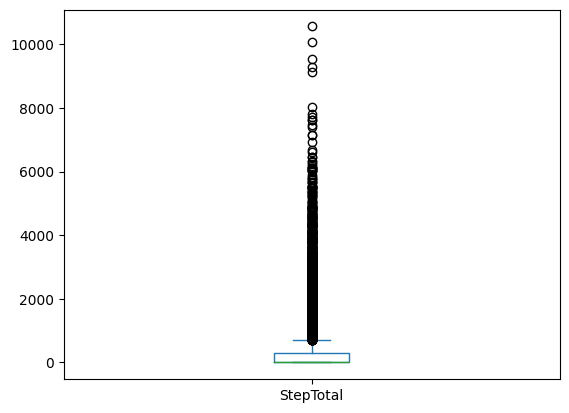

In [63]:
df['StepTotal'].plot.box()

# Gráfico pasos por hora



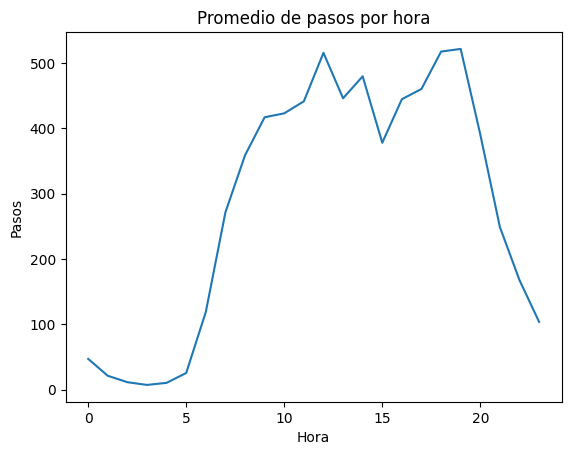

In [64]:
df.groupby('Hora')['StepTotal'].mean().plot(kind='line')

plt.title('Promedio de pasos por hora')
plt.xlabel('Hora')
plt.ylabel('Pasos')
plt.show()

# EXPORTAR DATASET LIMPIO

In [66]:
df.to_csv('/content/hourlySteps_clean.csv', index=False)

print("Dataset limpio guardado ✅")